###The data contains following information:
Demographic Information: Gender, Age.
Customer Relationship Metrics: Tenure with the company, satisfaction score.
Behavioral Data: Preferred login device, hours spent on the app, number of registered devices.
Transactional Data: Order count, days since the last order, cashback amount.
Logistical Information: City tier, distance from the warehouse to home.
Feedback/Complaint Data: Whether a customer has filed a complaint.
The target variable is Churn, which is a binary indicator (1 for churned, 0 for not churned).###

In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv('ecommerce_churn_data.csv')
df.head(50)

,CustomerID,Age,Gender,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,HoursSpentOnApp,NumberOfDevicesRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderCount,DaySinceLastOrder,CashbackAmount,Churn
0,56346,29,Male,5.0,Desktop,1,7.2,2.5,2,3,1,1,8,15,45.20,1
1,56347,45,Female,36.0,Mobile,3,20.1,4.8,4,5,3,0,50,2,320.50,0
2,56348,22,Male,2.0,Mobile,1,5.0,1.8,1,2,1,1,3,25,10.10,1
3,56349,39,Female,24.0,Desktop,2,15.3,3.9,3,4,2,0,35,5,210.90,0
4,56350,31,Male,12.0,Mobile,1,8.8,3.0,2,3,1,0,18,10,80.40,0
5,56351,50,Female,48.0,Mobile,3,22.5,5.5,4,5,4,0,60,1,400.00,0
6,56352,25,Male,3.0,Desktop,2,6.1,2.1,2,3,1,1,5,20,25.60,1
7,56353,36,Female,20.0,Mobile,1,9.5,3.5,3,4,2,0,22,8,120.30,0
8,56354,42,Male,30.0,Desktop,3,18.0,4.2,4,5,3,0,45,3,280.15,0
9,56355,28,Female,7.0,Mobile,2,11.0,2.8,2,3,1,0,10,12,55.80,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10205 entries, 0 to 10204
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CustomerID                 10205 non-null  int64  
 1   Age                        10205 non-null  int64  
 2   Gender                     10205 non-null  object 
 3   Tenure                     10204 non-null  float64
 4   PreferredLoginDevice       10205 non-null  object 
 5   CityTier                   10205 non-null  int64  
 6   WarehouseToHome            10205 non-null  float64
 7   HoursSpentOnApp            10205 non-null  float64
 8   NumberOfDevicesRegistered  10205 non-null  int64  
 9   SatisfactionScore          10205 non-null  int64  
 10  NumberOfAddress            10205 non-null  int64  
 11  Complain                   10205 non-null  int64  
 12  OrderCount                 10205 non-null  int64  
 13  DaySinceLastOrder          10205 non-null  int

In [5]:
df.isna().sum()
clean_df=df.dropna()
clean_df.isna().sum()
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10204 entries, 0 to 10204
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CustomerID                 10204 non-null  int64  
 1   Age                        10204 non-null  int64  
 2   Gender                     10204 non-null  object 
 3   Tenure                     10204 non-null  float64
 4   PreferredLoginDevice       10204 non-null  object 
 5   CityTier                   10204 non-null  int64  
 6   WarehouseToHome            10204 non-null  float64
 7   HoursSpentOnApp            10204 non-null  float64
 8   NumberOfDevicesRegistered  10204 non-null  int64  
 9   SatisfactionScore          10204 non-null  int64  
 10  NumberOfAddress            10204 non-null  int64  
 11  Complain                   10204 non-null  int64  
 12  OrderCount                 10204 non-null  int64  
 13  DaySinceLastOrder          10204 non-null  int64  


In [6]:
clean_df.duplicated().value_counts()

False    10204
Name: count, dtype: int64

In [7]:
clean_df.describe()

,CustomerID,Age,Tenure,CityTier,WarehouseToHome,HoursSpentOnApp,NumberOfDevicesRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderCount,DaySinceLastOrder,CashbackAmount,Churn
count,10204.000000,10204.000000,10204.000000,10204.000000,10204.000000,10204.000000,10204.000000,10204.000000,10204.000000,10204.000000,10204.000000,10204.000000,10204.000000,10204.000000
mean,29680.056546,35.194140,19.685515,2.007350,9.888103,3.343826,2.833889,3.504312,1.861917,0.216288,21.455312,8.892395,157.962814,0.238730
std,25617.860212,9.625265,14.475853,0.826782,5.481592,1.133228,0.921257,1.162855,0.920459,0.411733,18.956267,8.283932,107.628575,0.426328
min,307.000000,18.000000,1.000000,1.000000,0.500000,0.800000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5097.750000,28.000000,8.000000,1.000000,6.000000,2.500000,2.000000,3.000000,1.000000,0.000000,9.000000,3.000000,75.000000,0.000000
50%,9711.500000,33.000000,16.000000,2.000000,9.000000,3.400000,3.000000,4.000000,2.000000,0.000000,18.000000,6.000000,140.000000,0.000000
75%,56429.000000,42.000000,28.000000,3.000000,13.000000,4.100000,3.000000,4.000000,2.000000,0.000000,28.000000,12.000000,220.000000,0.000000
max,56760.000000,65.000000,85.000000,3.000000,35.000000,8.500000,5.000000,5.000000,5.000000,1.000000,250.000000,60.000000,1120.000000,1.000000


In [8]:
churn_rate=clean_df['Churn'].value_counts(normalize=True)*100
churn_rate

Churn
0    76.127009
1    23.872991
Name: proportion, dtype: float64

Churn rate shows approx 76 percent portion of our customers are retained with business while approx 24 percent are lost.

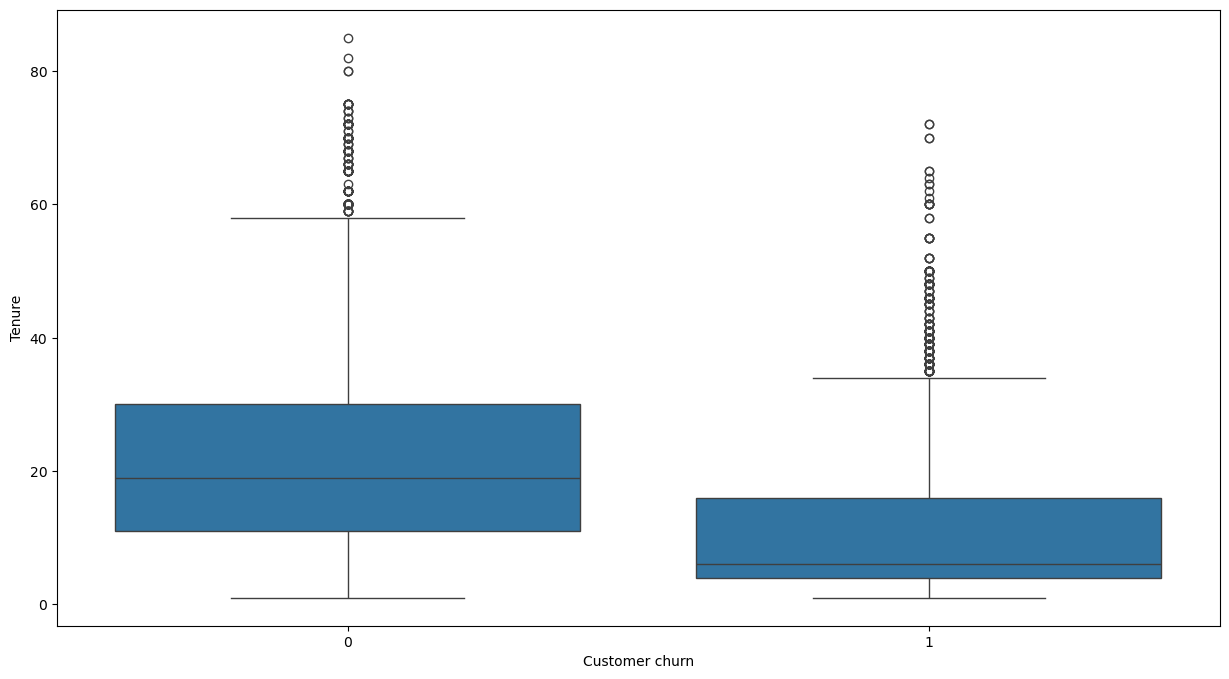

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(15,8))
sns.boxplot(x=clean_df['Churn'],y=clean_df['Tenure'])
plt.xlabel('Customer churn')
plt.ylabel('Tenure')
plt.show()

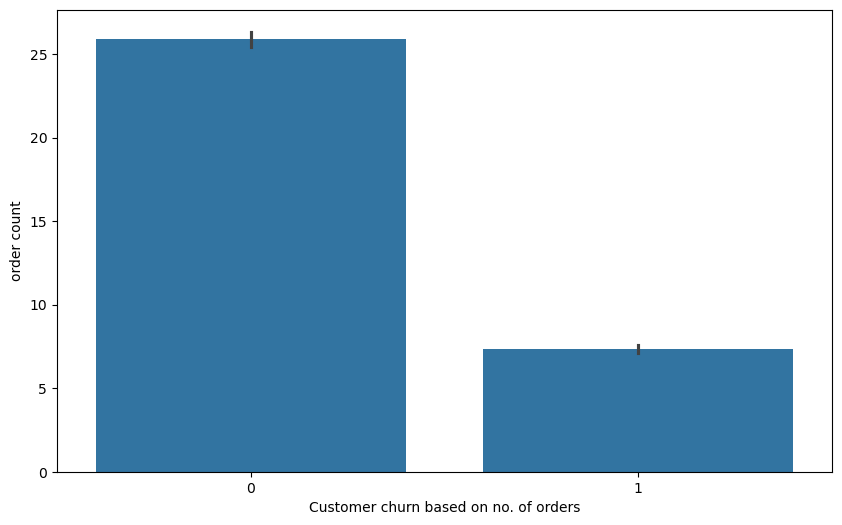

In [25]:
plt.figure(figsize=(10,6))
sns.barplot(x=clean_df['Churn'],y=clean_df['OrderCount'])
plt.xlabel('Customer churn based on no. of orders')
plt.ylabel('order count')
plt.show()

Customers with orders count less than 10 show high probability to leave the app.

<Figure size 1000x600 with 0 Axes>

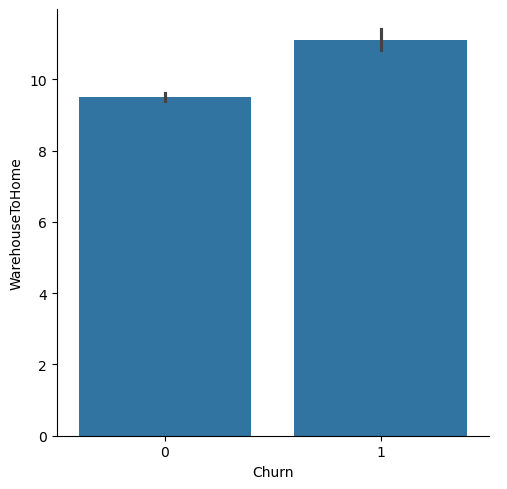

In [28]:
plt.figure(figsize=(10,6))
sns.catplot(kind='bar',x=clean_df['Churn'],y=clean_df['WarehouseToHome'])
plt.show()

<Figure size 1000x600 with 0 Axes>

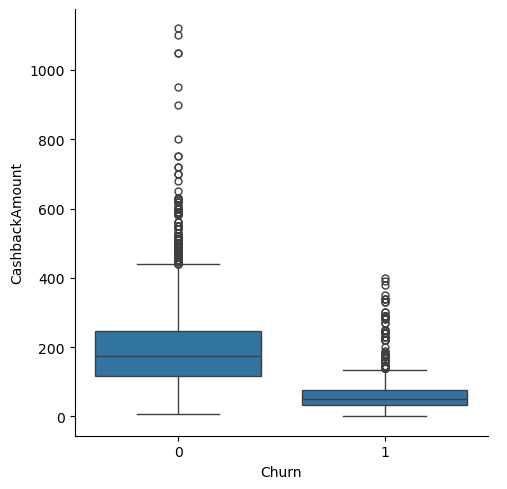

In [29]:
plt.figure(figsize=(10,6))
sns.catplot(kind='box',x=clean_df['Churn'],y=clean_df['CashbackAmount'])
plt.show()

In [65]:
clean_df['customer_complaint']=pd.cut(clean_df['Complain'],bins=[0,1,np.inf],labels=['low','high'])
clean_df.groupby('CustomerID')['OrderCount'].mean()
clean_df.groupby('customer_complaint')['Churn'].mean()

C:\Users\Vidushi\AppData\Local\Temp\ipykernel_25036\824105017.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  clean_df.groupby('customer_complaint')['Churn'].mean()


customer_complaint
low     0.970095
high         NaN
Name: Churn, dtype: float64

<Axes: xlabel='Churn', ylabel='customer_complaint'>

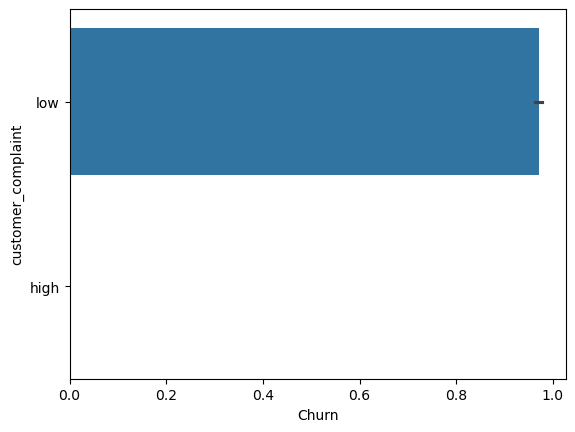

In [75]:

sns.barplot(data=clean_df,x='Churn',y='customer_complaint')

In [97]:
show=clean_df.groupby('CustomerID')['Complain'].sum()
show
no_of_complains=np.sum(clean_df['Complain']==1)
no_of_complains #2207 Total complaints


2207

In [104]:
avg_orderdays=clean_df.groupby('CustomerID')['DaySinceLastOrder'].mean()
clean_df['order_frequency']=pd.cut(clean_df['DaySinceLastOrder'],bins=[0,10,20,30,40,np.inf],labels=['high_value','potential_customer','moody','cashback_hunters','low_engagement'])
clean_df.groupby('order_frequency')['Churn'].mean()

C:\Users\Vidushi\AppData\Local\Temp\ipykernel_25036\4099365833.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  clean_df.groupby('order_frequency')['Churn'].mean()


order_frequency
high_value            0.098171
potential_customer    0.476611
moody                 0.760897
cashback_hunters      0.890805
low_engagement        1.000000
Name: Churn, dtype: float64

<Axes: xlabel='order_frequency', ylabel='Churn'>

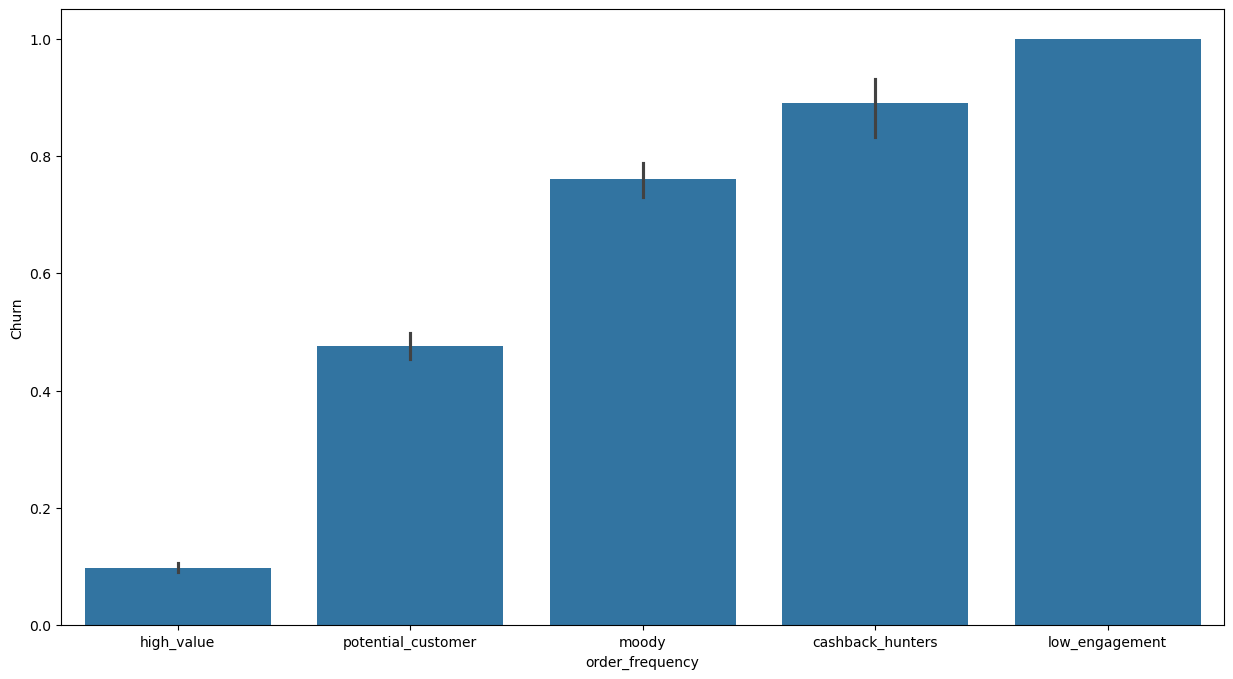

In [106]:
plt.figure(figsize=(15,8))
sns.barplot(data=clean_df,x='order_frequency',y='Churn')

In [116]:
correlation_matrix = clean_df[['Complain','Tenure','OrderCount','Churn']].corr()
correlation_matrix

,Complain,Tenure,OrderCount,Churn
Complain,1.000000,-0.269404,-0.366088,0.901258
Tenure,-0.269404,1.000000,0.567211,-0.295405
OrderCount,-0.366088,0.567211,1.000000,-0.416561
Churn,0.901258,-0.295405,-0.416561,1.000000


<Axes: >

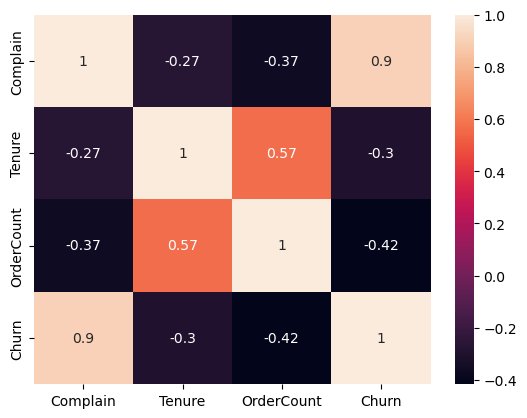

In [115]:
sns.heatmap(correlation_matrix, annot=True)

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

In [16]:
X = clean_df[['CityTier','HoursSpentOnApp','Complain','Tenure','OrderCount','CashbackAmount']]
y = clean_df["Churn"]
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)



In [19]:
model = RandomForestClassifier(n_estimators=100,class_weight="balanced",
    random_state=42)
model.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', random_state=42)

In [20]:
predictions = model.predict(X_test)
print(predictions[:20])

[0 0 0 1 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1]


In [21]:
y_prob = model.predict_proba(X_test)[:,1]
print(y_prob[:10])

[0.   0.   0.1  0.99 1.   0.   0.   0.   0.   0.  ]


In [22]:
importance = pd.Series(model.feature_importances_,index=X.columns)
print(importance.sort_values(ascending=False))

Complain           0.473146
CashbackAmount     0.211100
OrderCount         0.179686
Tenure             0.075994
HoursSpentOnApp    0.050333
CityTier           0.009740
dtype: float64


In [23]:
customer_ids=clean_df['CustomerID']

X_train, X_test, y_train, y_test, id_train, id_test = train_test_split(
    X, y, customer_ids, test_size=0.2, random_state=42, stratify=y
)

In [24]:
model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42
)
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [26]:
y1_pred = model.predict(X_test)
print('churn prediction',y1_pred[:20])
y1_prob = model.predict_proba(X_test)[:,1]
print('churn probability',y1_prob[:10])

churn prediction [0 0 0 0 0 0 0 0 0 1 0 1 0 1 1 1 0 0 0 1]
churn probability [0.   0.   0.01 0.   0.   0.   0.   0.   0.   1.  ]


In [31]:
churn_results = pd.DataFrame({
    'ChurnPrediction': y1_pred,
    'ChurnProbability': y1_prob
},index=id_test)

# #customers most at-risk first
churn_results = churn_results.sort_values(by='ChurnProbability', ascending=False)

print(churn_results.head(10))

            ChurnPrediction  ChurnProbability
CustomerID                                   
5898                      1               1.0
56446                     1               1.0
56539                     1               1.0
940                       1               1.0
9636                      1               1.0
56371                     1               1.0
7058                      1               1.0
56554                     1               1.0
56422                     1               1.0
56374                     1               1.0
